# Checkpoint 3 - Seleccio del model de desplegament

Avaluacio independent dels checkpoints de Fase 6 per decidir quin pes es desplega.

Aquest notebook esta pensat per executar-se **despres** d'haver acabat els runs de F6
(original i/o re-run), i comparar tots els checkpoints disponibles de cada carpeta.

Criteri de decisio (ordre):
1. Filtre de Nash: `exploit_vs_sl < 8 pp`.
2. Desempat principal: `metric_robust` maxima.
3. Desempat secundari: `std_pool` minima i `exploit_vs_sl` minim.

Tota l'avaluacio es **balancejada per posicio** (meitat ma, meitat post) amb `n=500`
partides per enfrontament.

> **Nota metodologica.** L'`exploit_vs_sl` es calcula contra el `sl_final.pt` de la
família del model (F6 original o re-run).

---

In [1]:
import sys, random, importlib
from pathlib import Path
import numpy as np
import pandas as pd
import torch, torch.nn as nn
import matplotlib.pyplot as plt
from gymnasium.spaces import Box

sys.path.insert(0, str(Path('../utils')))
from nb_utils import setup_pyplot
setup_pyplot()

BASE = Path('../../../')
ROOT = BASE.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Compat numpy 2.x (zips desats al servidor) -> numpy 1.x local
import numpy.core
sys.modules.setdefault('numpy._core', numpy.core)
for _sub in ['numeric','multiarray','umath','_multiarray_umath','numerictypes',
             '_methods','fromnumeric','_dtype','overrides','shape_base']:
    try:
        sys.modules.setdefault(f'numpy._core.{_sub}', importlib.import_module(f'numpy.core.{_sub}'))
    except ImportError:
        pass

from stable_baselines3 import PPO
from RL.models.sb3.sb3_features_extractor import CosMultiInputSB3
from RL.models.sb3.sb3_adapter import SB3PPOEvalAgent
from RL.models.nfsp.average_policy import AveragePolicyNet, SLAgent
from RL.entrenament.entrenamentsComparatius.fase5.entrenament_fase5 import _jugar_partida_sencera
from RL.entrenament.entrenamentsComparatius.fase4.pool_oponents import crear_oponent

RUN_DIRS = {
    'f6': (BASE / 'TFG_Doc/notebooks/6_nfsp/resultats/ppo_nfsp').resolve()
}

# Ordre de prioritat amb que volem provar checkpoints
CKPT_NAMES = ['best_nash', 'best_robust', 'best_calib', 'best', 'final']

VARIANTS = ['conservador','agressiu','truc_bot','envit_bot','faroler','equilibrat']
N_GAMES  = 1000

for k, p in RUN_DIRS.items():
    print(f"{k:<6} existeix: {p.exists()} -> {p}")
print('N_GAMES:', N_GAMES)

f6     existeix: True -> C:\Users\ferri\Documents\ProjectesCodi\TFG-truc\TFG_Doc\notebooks\6_nfsp\resultats\ppo_nfsp
N_GAMES: 1000


---

In [2]:
def carregar_sl(sl_path):
    """Carrega SLAgent des del state_dict complet (inclou pesos COS)."""
    sd = torch.load(str(sl_path), map_location='cpu', weights_only=True)
    net = object.__new__(AveragePolicyNet)
    nn.Module.__init__(net)
    net.cos = CosMultiInputSB3(observation_space=Box(low=-1, high=1, shape=(240,)), features_dim=256)
    layers, in_dim = [], 256
    for h in (256, 256):
        layers += [nn.Linear(in_dim, h), nn.ReLU()]
        in_dim = h
    layers += [nn.Linear(in_dim, 24)]
    net.head = nn.Sequential(*layers)
    net.load_state_dict(sd)
    return SLAgent(net=net, device='cpu', deterministic=False, seed=42)

def carregar_ppo(zip_path):
    """Carrega un PPO .zip de SB3 (tolerant amb l'optimitzador)."""
    _orig = PPO.set_parameters
    def _patch(self, d, exact_match=True, device='auto'):
        if isinstance(d, dict):
            d = {k: v for k, v in d.items() if 'optimizer' not in k}
        return _orig(self, d, exact_match=False, device=device)
    PPO.set_parameters = _patch
    try:
        model = PPO.load(str(zip_path), custom_objects={'features_extractor_class': CosMultiInputSB3}, device='cpu')
    finally:
        PPO.set_parameters = _orig
    return SB3PPOEvalAgent(model=model, n_actions=24)

def wr_bal(a, b, n=N_GAMES, seed=77777):
    """WR d'a contra b, balancejat per posicio (meitat ma, meitat post)."""
    rng = random.Random(seed)
    wins = 0
    for i in range(n):
        if i % 2 == 0:
            wins += int(_jugar_partida_sencera(a, b, rng))
        else:
            wins += int(not _jugar_partida_sencera(b, a, rng))
    return 100.0 * wins / n

def construir_candidats(run_dirs, ckpt_names):
    candidats = {}
    sl_map = {}
    meta = []
    for fam, run_dir in run_dirs.items():
        sl_path = run_dir / 'sl_final.pt'
        if not sl_path.exists():
            print(f"[WARN] No s'ha trobat SL per {fam}: {sl_path}")
            continue
        sl_agent = carregar_sl(sl_path)
        for ck in ckpt_names:
            zp = run_dir / f'{ck}.zip'
            if not zp.exists():
                continue
            nom = f"{fam}_{ck}"
            candidats[nom] = carregar_ppo(zp)
            sl_map[nom] = sl_agent
            meta.append({'model': nom, 'family': fam, 'checkpoint': ck, 'path': str(zp), 'sl_path': str(sl_path)})
    return candidats, sl_map, pd.DataFrame(meta)

candidats, SL_MAP, meta_models = construir_candidats(RUN_DIRS, CKPT_NAMES)
if len(candidats) == 0:
    raise FileNotFoundError('No s ha pogut carregar cap checkpoint .zip de les carpetes configurades.')

display(meta_models)
print('\nCandidats carregats:', list(candidats))

,model,family,checkpoint,path,sl_path
0,f6_best_nash,f6,best_nash,C:\Users\ferri\Documents\ProjectesCodi\TFG-tru...,C:\Users\ferri\Documents\ProjectesCodi\TFG-tru...
1,f6_best_robust,f6,best_robust,C:\Users\ferri\Documents\ProjectesCodi\TFG-tru...,C:\Users\ferri\Documents\ProjectesCodi\TFG-tru...
2,f6_best_calib,f6,best_calib,C:\Users\ferri\Documents\ProjectesCodi\TFG-tru...,C:\Users\ferri\Documents\ProjectesCodi\TFG-tru...
3,f6_best,f6,best,C:\Users\ferri\Documents\ProjectesCodi\TFG-tru...,C:\Users\ferri\Documents\ProjectesCodi\TFG-tru...
4,f6_final,f6,final,C:\Users\ferri\Documents\ProjectesCodi\TFG-tru...,C:\Users\ferri\Documents\ProjectesCodi\TFG-tru...



Candidats carregats: ['f6_best_nash', 'f6_best_robust', 'f6_best_calib', 'f6_best', 'f6_final']


---

In [3]:
# Càlcul de WR pool per cada candidat, robustesa i exploit
files = []
wr_per_variant = {}
for nom, ag in candidats.items():
    wrs = {v: wr_bal(ag, crear_oponent(v, seed=42), n=N_GAMES, seed=10000) for v in VARIANTS}
    wr_per_variant[nom] = wrs
    mean = float(np.mean(list(wrs.values())))
    std  = float(np.std(list(wrs.values())))
    mr   = mean - 0.5 * std
    fila = {'model': nom, 'wr_pool_mean': mean, 'std_pool': std, 'metric_robust': mr}
    wr_sl = wr_bal(ag, SL_MAP[nom], n=N_GAMES, seed=20000)
    fila['exploit_vs_sl'] = abs(wr_sl - 50.0)
    files.append(fila)
    print(f"  {nom:<16} mr={mr:5.1f}%  std={std:4.1f}  exploit={fila['exploit_vs_sl']:.1f}")

df = pd.DataFrame(files).set_index('model')
df

  f6_best_nash     mr= 64.4%  std= 5.1  exploit=0.7
  f6_best_robust   mr= 63.8%  std= 6.0  exploit=2.5
  f6_best_calib    mr= 61.9%  std= 6.0  exploit=3.4
  f6_best          mr= 62.7%  std= 5.9  exploit=0.4
  f6_final         mr= 60.7%  std= 6.2  exploit=2.6


,wr_pool_mean,std_pool,metric_robust,exploit_vs_sl
model,,,,
f6_best_nash,66.983333,5.146331,64.410168,0.7
f6_best_robust,66.783333,5.968924,63.798871,2.5
f6_best_calib,64.933333,6.015720,61.925473,3.4
f6_best,65.616667,5.924361,62.654486,0.4
f6_final,63.766667,6.233155,60.650089,2.6


---

In [4]:
# Resum: taula WR + exploitabilitat per candidat
LLINDAR_NASH = 8.0

taula = df.copy()
taula['compleix_nash'] = taula['exploit_vs_sl'] < LLINDAR_NASH

print(f'=== Resum candidats (n={N_GAMES}, balancejat) ===')
print(taula.round(2).to_string())

=== Resum candidats (n=1000, balancejat) ===
                wr_pool_mean  std_pool  metric_robust  exploit_vs_sl  compleix_nash
model                                                                              
f6_best_nash           66.98      5.15          64.41            0.7           True
f6_best_robust         66.78      5.97          63.80            2.5           True
f6_best_calib          64.93      6.02          61.93            3.4           True
f6_best                65.62      5.92          62.65            0.4           True
f6_final               63.77      6.23          60.65            2.6           True


---

Figura desada a C:\Users\ferri\Documents\ProjectesCodi\TFG-truc\TFG_Doc\Memoria\figures\checkpoint3\comparacio_candidats.pdf


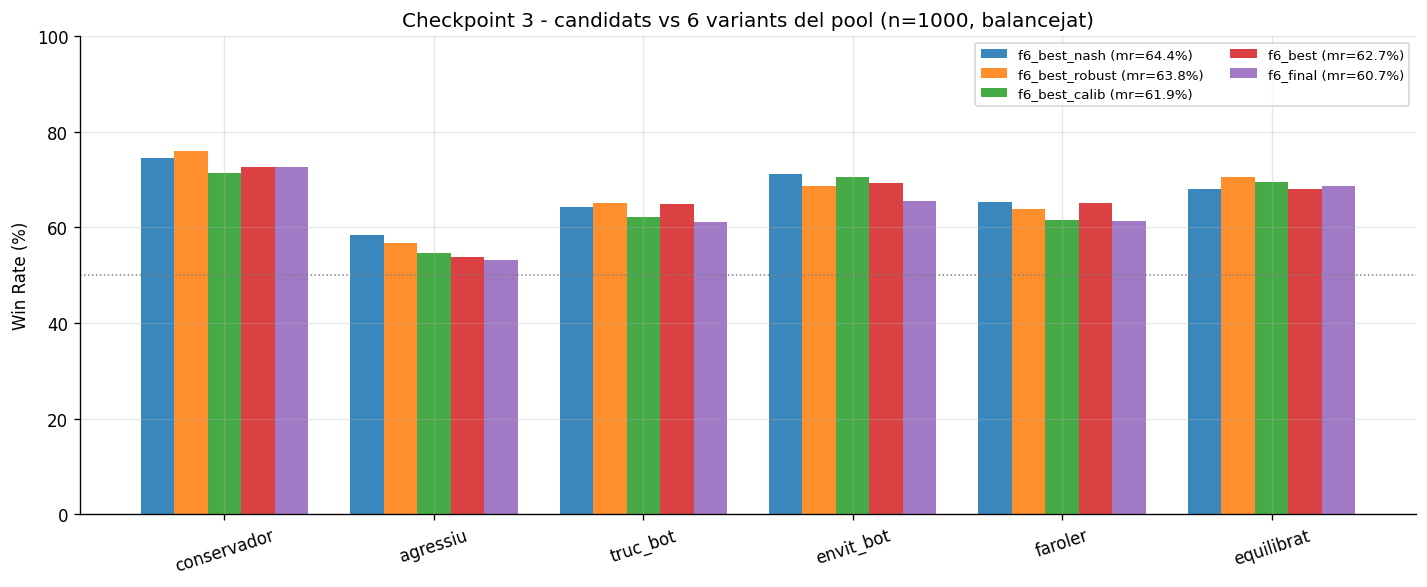

In [5]:
# Figura: WR per variant dels candidats + mitjana
models = list(candidats)
cmap = plt.get_cmap('tab10')
COLORS = {m: cmap(i % 10) for i, m in enumerate(models)}

x = np.arange(len(VARIANTS))
w = 0.8 / len(models)

fig, ax = plt.subplots(figsize=(12, 5))
for j, nom in enumerate(models):
    vals = [wr_per_variant[nom][v] for v in VARIANTS]
    ax.bar(
        x + (j - (len(models)-1)/2) * w, vals, width=w,
        label=f"{nom} (mr={df.loc[nom,'metric_robust']:.1f}%)",
        color=COLORS[nom], alpha=0.88
    )
ax.axhline(50, color='gray', ls=':', lw=0.9)
ax.set_xticks(x); ax.set_xticklabels(VARIANTS, rotation=18)
ax.set_ylabel('Win Rate (%)'); ax.set_ylim(0, 100)
ax.set_title(f'Checkpoint 3 - candidats vs 6 variants del pool (n={N_GAMES}, balancejat)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()

FIG_DIR = (BASE / 'TFG_Doc/Memoria/figures/checkpoint3').resolve()
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / 'comparacio_candidats.pdf', bbox_inches='tight')
print('Figura desada a', FIG_DIR / 'comparacio_candidats.pdf')
plt.show()
plt.close(fig)

---

## Anàlisi 2 — Perfil de comportament global

Per a 300 partides com a jugador 0 contra `equilibrat`, es registra la freqüència amb
la qual cada model adopta cada aposta **quan l'acció és disponible** (màscara legal):

| Mètrica | Definició |
|---------|-----------|
| **Taxa envidar** | P(apostar\_envit \| apostar\_envit ∈ accions\_legals) |
| **Taxa trucar** | P(apostar\_truc \| apostar\_truc ∈ accions\_legals) |
| **Taxa acc. envit** | P(vull\_envit \| envit\_pendent) |
| **Taxa acc. truc** | P(vull\_truc \| truc\_pendent) |

  f6_best_nash: 2412 dec. truc, 1739 dec. envit, 681 resp. truc, 434 resp. envit
  f6_best_robust: 2516 dec. truc, 1832 dec. envit, 684 resp. truc, 463 resp. envit
  f6_best_calib: 2432 dec. truc, 1654 dec. envit, 747 resp. truc, 409 resp. envit
  f6_best: 2760 dec. truc, 1751 dec. envit, 760 resp. truc, 497 resp. envit
  f6_final: 2681 dec. truc, 1659 dec. envit, 757 resp. truc, 460 resp. envit

Anàlisi 3 — Perfil de comportament (n=300 partides vs equilibrat)
                Taxa envidar (%)  Taxa trucar (%)  Taxa acc. envit (%)  Taxa acc. truc (%)
f6_best_nash                23.9             75.0                 46.3                69.5
f6_best_robust              32.5             72.4                 33.9                73.4
f6_best_calib               22.4             70.8                 44.5                77.9
f6_best                     23.2             69.1                 41.4                64.7
f6_final                    25.4             68.3                 38.7         

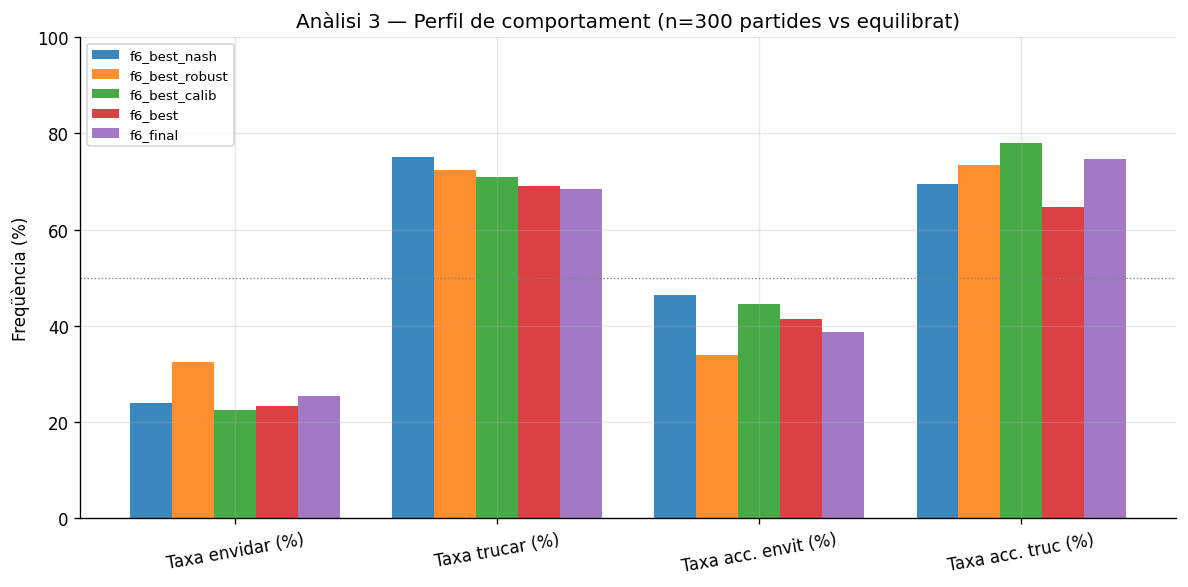

In [6]:
from joc.entorn.cartes_accions import ACTION_SPACE
from RL.models.model_propi.agent_regles import AgentRegles

ar_ref = AgentRegles(num_actions=24, seed=0)

class AgentLogger:
    """Intercepta eval_step i registra decisions de trucar/envidar amb context de mà."""
    use_raw = False
    def __init__(self, agent):
        self.agent = agent; self.reset()
    def reset(self):
        self.decisions = []
    def eval_step(self, state):
        action, info = self.agent.eval_step(state)
        legal = state['legal_actions']
        raw   = state.get('raw_obs', {})
        rs    = raw.get('response_state_val', 0)
        lt    = ACTION_SPACE['apostar_truc']  in legal
        le    = ACTION_SPACE['apostar_envit'] in legal
        lvt   = ACTION_SPACE['vull_truc']    in legal
        lve   = ACTION_SPACE['vull_envit']   in legal
        if lt or le or lvt or lve:
            self.decisions.append({
                'response_state':  rs,
                'hand_strength':   ar_ref._hand_strength(raw),
                'envit_score':     ar_ref._envit_score(raw),
                'legal_truc':      lt,  'legal_envit':       le,
                'legal_vull_truc': lvt, 'legal_vull_envit':  lve,
                'obre_truc':    lt  and action == ACTION_SPACE['apostar_truc'],
                'obre_envit':   le  and action == ACTION_SPACE['apostar_envit'],
                'accepta_truc': lvt and action == ACTION_SPACE['vull_truc'],
                'accepta_envit':lve and action == ACTION_SPACE['vull_envit'],
            })
        return action, info

N_LOG = 300
loggers = {}
for nom, ag in candidats.items():
    lg = AgentLogger(ag)
    oponent_l = crear_oponent('equilibrat', seed=42)
    rng_l = random.Random(55555)
    for _ in range(N_LOG):
        _jugar_partida_sencera(lg, oponent_l, rng_l)
    loggers[nom] = lg
    d = pd.DataFrame(lg.decisions)
    print(f"  {nom}: {d['legal_truc'].sum()} dec. truc, {d['legal_envit'].sum()} dec. envit, "
          f"{d['legal_vull_truc'].sum()} resp. truc, {d['legal_vull_envit'].sum()} resp. envit")

# Taula de taxes (Perfil de comportament)
perfils = {}
for nom, lg in loggers.items():
    d = pd.DataFrame(lg.decisions)
    t = d[d['legal_truc']];  e = d[d['legal_envit']]
    vt = d[d['legal_vull_truc']]; ve = d[d['legal_vull_envit']]
    perfils[nom] = {
        'Taxa envidar (%)':    e['obre_envit'].mean()*100   if len(e)  else 0,
        'Taxa trucar (%)':     t['obre_truc'].mean()*100    if len(t)  else 0,
        'Taxa acc. envit (%)': ve['accepta_envit'].mean()*100 if len(ve) else 0,
        'Taxa acc. truc (%)':  vt['accepta_truc'].mean()*100  if len(vt) else 0,
    }
df_perf = pd.DataFrame(perfils).T
print(f'\nAnàlisi 3 — Perfil de comportament (n={N_LOG} partides vs equilibrat)')
print(df_perf.round(1).to_string())

# Figura barres
cats = list(df_perf.columns)
x = np.arange(len(cats))
w = 0.8 / len(candidats)
fig, ax = plt.subplots(figsize=(10, 5))
for j, (nom, row) in enumerate(df_perf.iterrows()):
    ax.bar(x + (j - (len(candidats)-1)/2)*w, row.values, width=w,
           label=nom, color=COLORS.get(nom), alpha=0.88)
ax.set_xticks(x); ax.set_xticklabels(cats, rotation=10)
ax.set_ylabel('Freqüència (%)'); ax.set_ylim(0, 100)
ax.axhline(50, ls=':', lw=0.8, color='gray')
ax.set_title(f'Anàlisi 3 — Perfil de comportament (n={N_LOG} partides vs equilibrat)')
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(FIG_DIR / 'perfil_comportament.pdf', bbox_inches='tight')
print('Figura desada a', FIG_DIR / 'perfil_comportament.pdf')
plt.show(); plt.close(fig)

---

## Anàlisi 3 — Calibració estratègica

Correlació entre la **força de la mà** i la **decisió d'apostar** quan l'acció és disponible,
extreta amb els mateixos mètodes que `AgentRegles` per garantir la coherència dels valors.

- **Gràfic esquerre**: `hand_strength` (0–1, rang truc normalitzat) vs. taxa d'obrir truc.
- **Gràfic dret**: `envit_score` (punts d'envit de la mà) vs. taxa d'obrir envit.

Figura desada a C:\Users\ferri\Documents\ProjectesCodi\TFG-truc\TFG_Doc\Memoria\figures\checkpoint3\calibracio_estrategica.pdf


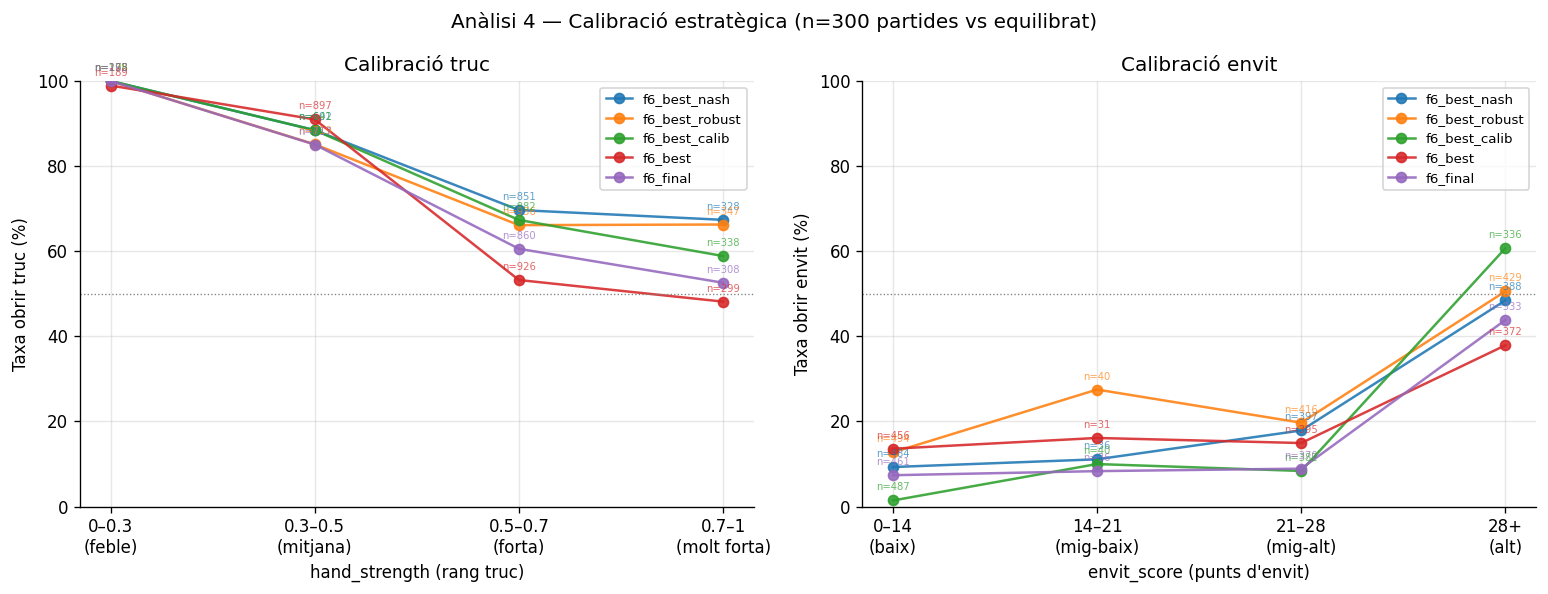

In [7]:
TRUC_BINS  = [0, 0.30, 0.50, 0.70, 1.01]
TRUC_LABS  = ['0–0.3\n(feble)', '0.3–0.5\n(mitjana)', '0.5–0.7\n(forta)', '0.7–1\n(molt forta)']
ENVIT_BINS = [0, 14, 21, 28, 50]
ENVIT_LABS = ['0–14\n(baix)', '14–21\n(mig-baix)', '21–28\n(mig-alt)', '28+\n(alt)']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for nom, lg in loggers.items():
    color = COLORS.get(nom)
    df_d = pd.DataFrame(lg.decisions)
    if df_d.empty: continue

    # Calibració truc: hand_strength vs obre_truc (rs0, legal_truc)
    sub_t = df_d[df_d['legal_truc'] & (df_d['response_state'] == 0)].copy()
    if not sub_t.empty:
        sub_t['bucket'] = pd.cut(sub_t['hand_strength'], TRUC_BINS, labels=TRUC_LABS, right=False)
        grp = sub_t.groupby('bucket', observed=False)['obre_truc'].agg(['mean','count'])
        vals = grp['mean'].values * 100
        ax1.plot(range(len(TRUC_LABS)), vals, 'o-', label=nom, color=color, alpha=0.88, markersize=6)
        for i, (v, n) in enumerate(zip(vals, grp['count'])):
            if not np.isnan(v):
                ax1.annotate(f'n={int(n)}', (i, v), textcoords='offset points',
                             xytext=(0, 6), fontsize=6, ha='center', color=color, alpha=0.7)

    # Calibració envit: envit_score vs obre_envit (rs0, legal_envit)
    sub_e = df_d[df_d['legal_envit'] & (df_d['response_state'] == 0)].copy()
    if not sub_e.empty:
        sub_e['bucket'] = pd.cut(sub_e['envit_score'], ENVIT_BINS, labels=ENVIT_LABS, right=False)
        grp2 = sub_e.groupby('bucket', observed=False)['obre_envit'].agg(['mean','count'])
        vals2 = grp2['mean'].values * 100
        ax2.plot(range(len(ENVIT_LABS)), vals2, 'o-', label=nom, color=color, alpha=0.88, markersize=6)
        for i, (v, n) in enumerate(zip(vals2, grp2['count'])):
            if not np.isnan(v):
                ax2.annotate(f'n={int(n)}', (i, v), textcoords='offset points',
                             xytext=(0, 6), fontsize=6, ha='center', color=color, alpha=0.7)

ax1.set_xticks(range(len(TRUC_LABS))); ax1.set_xticklabels(TRUC_LABS)
ax1.set_xlabel('hand_strength (rang truc)'); ax1.set_ylabel('Taxa obrir truc (%)')
ax1.set_title('Calibració truc'); ax1.set_ylim(0, 100)
ax1.axhline(50, ls=':', lw=0.8, color='gray'); ax1.legend(fontsize=8)

ax2.set_xticks(range(len(ENVIT_LABS))); ax2.set_xticklabels(ENVIT_LABS)
ax2.set_xlabel("envit_score (punts d'envit)"); ax2.set_ylabel('Taxa obrir envit (%)')
ax2.set_title('Calibració envit'); ax2.set_ylim(0, 100)
ax2.axhline(50, ls=':', lw=0.8, color='gray'); ax2.legend(fontsize=8)

plt.suptitle(f'Anàlisi 4 — Calibració estratègica (n={N_LOG} partides vs equilibrat)')
plt.tight_layout()
fig.savefig(FIG_DIR / 'calibracio_estrategica.pdf', bbox_inches='tight')
print('Figura desada a', FIG_DIR / 'calibracio_estrategica.pdf')
plt.show(); plt.close(fig)

---

## Criteri de decisió final

Síntesi de les 4 anàlisis per seleccionar el model de desplegament:

| Anàlisi | Mesura | Criteri |
|---------|--------|---------|
| 1 — WR pool + exploit | `exploit_vs_sl`, `metric_robust` | Nash gap < 8 pp → desempat per `metric_robust` |
| 2 — Resum taula | Taula completa | Confirmació visual |
| 3 — Perfil comportament | Taxes d'aposta | Coherència estratègica (ni massa passiu ni massa agressiu) |
| 4 — Calibració | Força↔aposta | Correlació positiva esperada |

In [8]:
print("=" * 68)
print("CRITERI DE DECISIO FINAL (checkpoint -> desplegament)")
print("=" * 68)
print()

# 1) Filtre Nash
sota_llindar = taula[taula['compleix_nash']].copy()
if len(sota_llindar):
    # 2) Desempat: metric_robust max
    mr_max = sota_llindar['metric_robust'].max()
    top = sota_llindar[sota_llindar['metric_robust'] == mr_max].copy()
    # 3) Desempat secundari: std min, exploit min
    top = top.sort_values(['std_pool', 'exploit_vs_sl'])
    triat = top.index[0]
    print(f"[Anàlisi 1+2] Nash OK (<{LLINDAR_NASH} pp): {list(sota_llindar.index)}")
    print(f"   Seleccionat: {triat}")
    print(f"   exploit={taula.loc[triat,'exploit_vs_sl']:.1f} pp  "
          f"metric_robust={taula.loc[triat,'metric_robust']:.1f}%  "
          f"std={taula.loc[triat,'std_pool']:.1f}")
else:
    # Fallback robustesa si cap model compleix Nash
    fallback = taula.sort_values(['metric_robust', 'std_pool', 'exploit_vs_sl'], ascending=[False, True, True])
    triat = fallback.index[0]
    print(f"[Anàlisi 1+2] Cap model sota Nash; fallback per robustesa: {triat}")

print()
print("[Anàlisi 3] Taxes d'aposta quan l'accio es legal:")
for nom, p in perfils.items():
    mark = "  <-" if nom == triat else ""
    print(f"   {nom:<22} envidar={p['Taxa envidar (%)']:4.0f}%  "
          f"trucar={p['Taxa trucar (%)']:4.0f}%  "
          f"acc_envit={p['Taxa acc. envit (%)']:4.0f}%  "
          f"acc_truc={p['Taxa acc. truc (%)']:4.0f}%{mark}")

# Export de la decisio de desplegament
row_meta = meta_models[meta_models['model'] == triat].iloc[0]
deploy_path = Path(row_meta['path'])
deploy_dir = (BASE / 'TFG_Doc/notebooks/7_checkpoint3/resultats').resolve()
deploy_dir.mkdir(parents=True, exist_ok=True)

out_txt = deploy_dir / 'model_desplegament.txt'
out_md = deploy_dir / 'model_desplegament.md'
out_json = deploy_dir / 'model_desplegament.json'

out_txt.write_text(str(deploy_path), encoding='utf-8')
out_md.write_text(
    "# Model de desplegament (Checkpoint 3)\n\n"
    f"- model: {triat}\n"
    f"- family: {row_meta['family']}\n"
    f"- checkpoint: {row_meta['checkpoint']}\n"
    f"- path: {deploy_path}\n"
    f"- metric_robust: {taula.loc[triat,'metric_robust']:.2f}\n"
    f"- std_pool: {taula.loc[triat,'std_pool']:.2f}\n"
    f"- exploit_vs_sl: {taula.loc[triat,'exploit_vs_sl']:.2f}\n",
    encoding='utf-8'
 )
pd.DataFrame([{
    'model': triat,
    'family': row_meta['family'],
    'checkpoint': row_meta['checkpoint'],
    'path': str(deploy_path),
    'metric_robust': float(taula.loc[triat,'metric_robust']),
    'std_pool': float(taula.loc[triat,'std_pool']),
    'exploit_vs_sl': float(taula.loc[triat,'exploit_vs_sl']),
}]).to_json(out_json, orient='records', indent=2)

print()
print(f">>> MODEL DE DESPLEGAMENT: {triat}")
print(f"    Pes seleccionat: {deploy_path}")
print(f"    Exportat a: {out_txt}")

CRITERI DE DECISIO FINAL (checkpoint -> desplegament)

[Anàlisi 1+2] Nash OK (<8.0 pp): ['f6_best_nash', 'f6_best_robust', 'f6_best_calib', 'f6_best', 'f6_final']
   Seleccionat: f6_best_nash
   exploit=0.7 pp  metric_robust=64.4%  std=5.1

[Anàlisi 3] Taxes d'aposta quan l'accio es legal:
   f6_best_nash           envidar=  24%  trucar=  75%  acc_envit=  46%  acc_truc=  69%  <-
   f6_best_robust         envidar=  33%  trucar=  72%  acc_envit=  34%  acc_truc=  73%
   f6_best_calib          envidar=  22%  trucar=  71%  acc_envit=  44%  acc_truc=  78%
   f6_best                envidar=  23%  trucar=  69%  acc_envit=  41%  acc_truc=  65%
   f6_final               envidar=  25%  trucar=  68%  acc_envit=  39%  acc_truc=  75%

>>> MODEL DE DESPLEGAMENT: f6_best_nash
    Pes seleccionat: C:\Users\ferri\Documents\ProjectesCodi\TFG-truc\TFG_Doc\notebooks\6_nfsp\resultats\ppo_nfsp\best_nash.zip
    Exportat a: C:\Users\ferri\Documents\ProjectesCodi\TFG-truc\TFG_Doc\notebooks\7_checkpoint3\result

---

## Conclusions

Aquesta execucio ha comparat 5 checkpoints de `ppo_nfsp` amb `n=1000` partides balancejades per posicio.

### Resum numeric
| Model | WR pool mean | std_pool | metric_robust | exploit_vs_sl | Nash OK (<8) |
|---|---:|---:|---:|---:|---|
| f6_best_nash | 66.98 | 5.15 | **64.41** | 0.7 | Sí |
| f6_best_robust | 66.78 | 5.97 | 63.80 | 2.5 | Sí |
| f6_best_calib | 64.93 | 6.02 | 61.93 | 3.4 | Sí |
| f6_best | 65.62 | 5.92 | 62.65 | **0.4** | Sí |
| f6_final | 63.77 | 6.23 | 60.65 | 2.6 | Sí |

### Decisio de desplegament
Com que tots els candidats compleixen el gate de Nash (`exploit_vs_sl < 8 pp`), el desempat principal per `metric_robust` selecciona **f6_best_nash**.

- Model triat: **f6_best_nash**
- Pes de desplegament: `TFG_Doc/notebooks/6_nfsp/resultats/ppo_nfsp/best_nash.zip`
- Export oficial: `TFG_Doc/notebooks/7_checkpoint3/resultats/model_desplegament.txt`

### Lectura estrategica (Anàlisi 3)
El model triat manté un perfil equilibrat respecte als altres candidats:
- `Taxa envidar`: 24%
- `Taxa trucar`: 75%
- `Taxa acc. envit`: 46%
- `Taxa acc. truc`: 69%

Això reforça la tria: bon compromís entre in-explotabilitat (`0.7 pp`) i robustesa global (`64.41`).